# 02 · DES SN5YR SNe

Four cosmological scenarios over **DES SN5YR** (1820–1829 SNe Ia, distance
modulus already calibrated).

### Key differences vs Pantheon+ (notebook 01)

- **NO Cepheids**: the DES Hubble Diagram already provides calibrated mu (not raw
  m_b). The absolute magnitude offset is marginalized analytically with
  `chi2 - B^2/C + log(C / (2 pi))`.
- **H0 fixed at 70 km/s/Mpc** in all scenarios: without a Cepheid anchor, BAO
  only measures the geometry of the expansion, not H0.
- **DA instead of DL**: chi2 uses `mu = 5 * log10[(1 + zHD) * (1 + zHEL) * DA] + 25`
  via `angular_diameter_distance` (equivalent but faster than DL).
- **2024 vs 2025**: two releases with different covariance formats
  (see `cosmoml/data/des.py`).

Shared pipeline: `train_xgb(log_target=True)` with model cache, contours at
`res=100, sigma=2.0, theory_threshold=12`.


## Index

| Sec. | Scenario              | Model        | Dim | Data |
|------|-----------------------|--------------|-----|------|
| [2.1](#2-1) | **wCDM, DES2024**       | FlatwCDM     | 2 (Om, w)       | DES SN5YR 2024 release |
| [2.2](#2-2) | **wCDM, DES2025**       | FlatwCDM     | 2 (Om, w)       | DES SN5YR 2025 release |
| [2.3](#2-3) | **w0waCDM, DES2024**    | Flatw0waCDM  | 3 (Om, w0, wa)  | DES SN5YR 2024 release |
| [2.4](#2-4) | **w0waCDM, DES2025**    | Flatw0waCDM  | 3 (Om, w0, wa)  | DES SN5YR 2025 release |

> **Cepheids**: NOT used in any DES scenario (DES has no external Cepheid
> calibrators, only the homogeneous Hubble Diagram).


## <a id="setup"></a>Setup (run first)


In [53]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_des_2024, load_des_2025
from cosmoml.theory import chi2_sne_des

from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR

use_paper_style()

NB_NAME = "02_SN_DES"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Set to True to retrain models (ignore cache)
FORCE_RETRAIN = False

print(f"Datasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Models:    {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figures:   {FIGURES_DIR}/{{SECTION}}_*.png")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Models:    /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figures:   /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/{SECTION}_*.png


## <a id="2-1"></a>2.1 wCDM with DES2024 — 2D (Om, w)

**Data:** DES-SN5YR release 2024 (1829 SNe).
**Model:** `FlatwCDM` with H0 = 70 fixed.
**Cepheids:** **NO**.

The 2024 `STAT+SYS_2024.txt.gz` matrix is the systematic covariance only — the
loader adds `MUERR_FINAL**2` to the diagonal before inverting.


In [54]:
SECTION = "2_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]
H0_FIXED = 70.0

des = load_des_2024()
print(f"DES SN5YR 2024: {len(des)} SNe, z [{des.z.min():.3f}, {des.z.max():.3f}]")

def chi2_fn(Om, w):
    return chi2_sne_des(des, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3, -1.0])))
_m.limits = [(0.05, 0.55), (-1.6, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2024: 1829 SNe, z [0.025, 1.121]
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2669  w=-0.8015
chi2(best-fit) = 1647.67


In [55]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[dict(Om=(max(0.05, REF['Om']-0.20), REF['Om']+0.20),
                     w=(REF['w']-0.50, REF['w']+0.50), _n=8_000)],
        anchor=REF, n_anchor=2000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_1_dataset.csv)
Evaluating chi2 at 8000 points across 11 cores...


     2000/8000 ( 25.0%) | elapsed   87.6s | ETA  262.9s |     23 pts/s
     4000/8000 ( 50.0%) | elapsed  170.6s | ETA  170.6s |     23 pts/s
     6000/8000 ( 75.0%) | elapsed  257.8s | ETA   85.9s |     23 pts/s
     8000/8000 (100.0%) | elapsed  312.2s | ETA    0.0s |     26 pts/s
  done in 312.3s
  anchor {'Om': 0.26685527465872433, 'w': -0.8014552186639804} -> chi2=1647.668 repeated 2000x
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_1_dataset.csv (10000 rows)
min chi2 = 1647.668


In [56]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)

  target in shifted-log10: range [0.000, 3.097]
  training: 14.81s | R2=0.99889 | best_iter=695/3000  (early stop, ~77% saved)
  model cached: 2_1_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_learning_curve.png


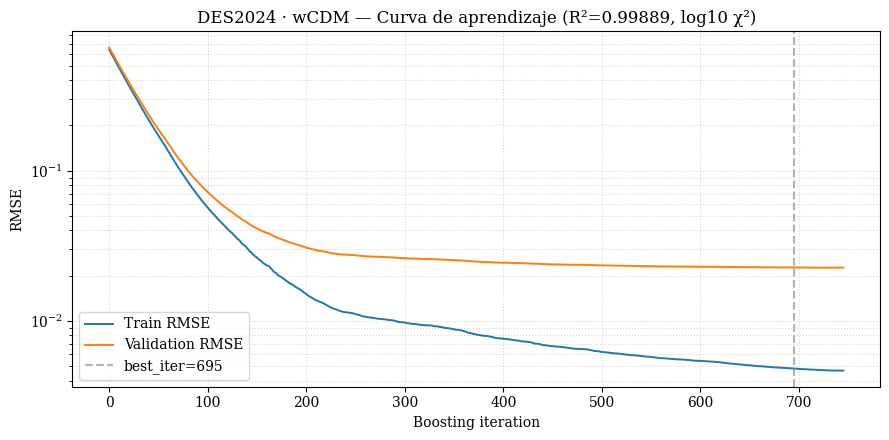

In [57]:
plot_learning_curve(
    info,
    title=f"DES2024 · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_Om_w.png


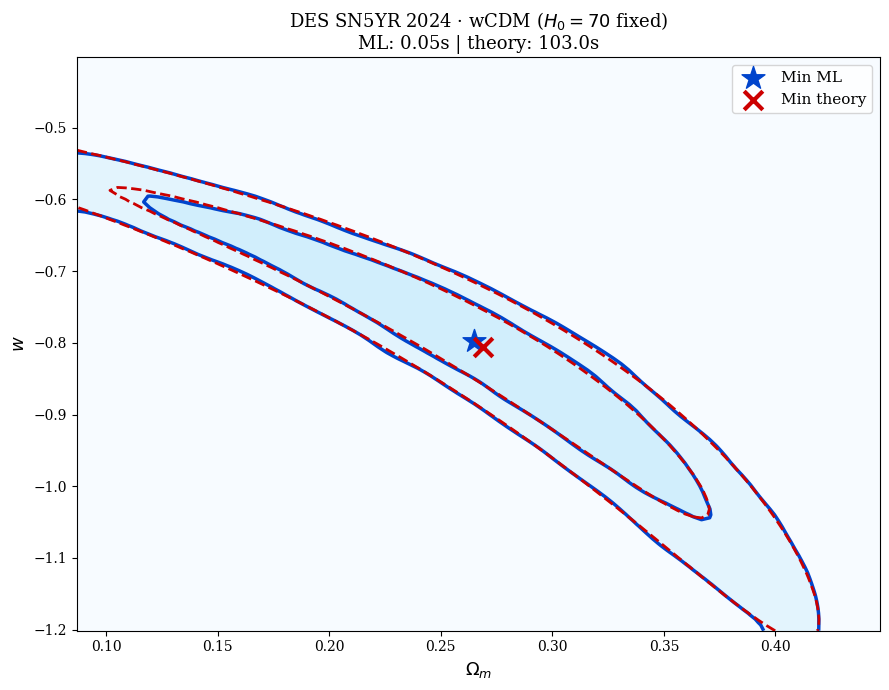

{'Z_ml': array([[2421.5474, 2411.3308, 2393.7507, ..., 1657.3551, 1657.8827,
         1658.1885],
        [2415.4006, 2405.2258, 2387.7065, ..., 1657.4391, 1657.976 ,
         1658.2869],
        [2403.967 , 2393.8728, 2376.4756, ..., 1657.5988, 1658.1531,
         1658.4736],
        ...,
        [1705.9371, 1706.5549, 1707.6359, ..., 1911.5531, 1913.0647,
         1913.9579],
        [1709.5543, 1710.1919, 1711.2972, ..., 1915.8374, 1917.3329,
         1918.2201],
        [1711.601 , 1712.2441, 1713.3538, ..., 1918.2758, 1919.7617,
         1920.6449]], shape=(100, 100), dtype=float32),
 'Z_th': array([[          nan,           nan,           nan, ..., 1657.08629027,
         1657.98568802, 1658.97947484],
        [          nan,           nan,           nan, ..., 1657.31675562,
         1658.26119402, 1659.29875621],
        [          nan,           nan,           nan, ..., 1657.57846446,
         1658.56764842, 1659.64869555],
        ...,
        [          nan,           nan,   

In [58]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(REF['Om']-0.18, REF['Om']+0.18),
    y_range=(REF['w']-0.40, REF['w']+0.40),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DES SN5YR 2024 · wCDM ($H_0=70$ fixed)",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w.png",
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_beeswarm.png


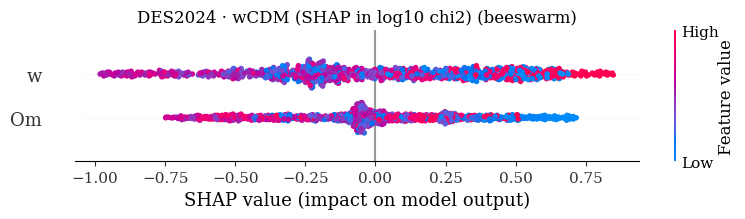

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_bar.png


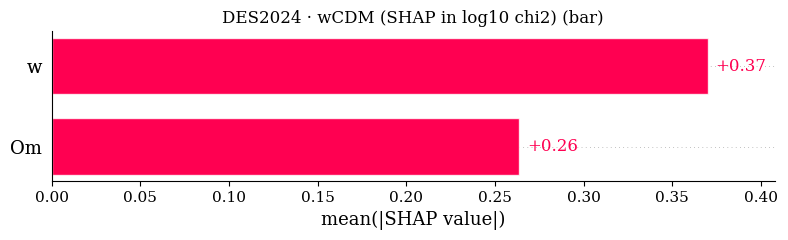

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_waterfall.png


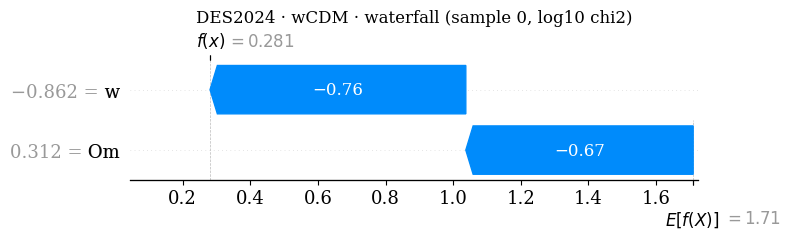

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

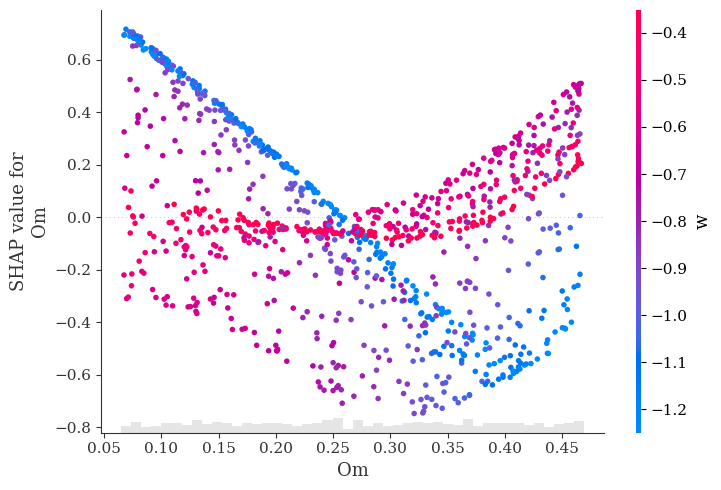

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_w.png


<Figure size 640x480 with 0 Axes>

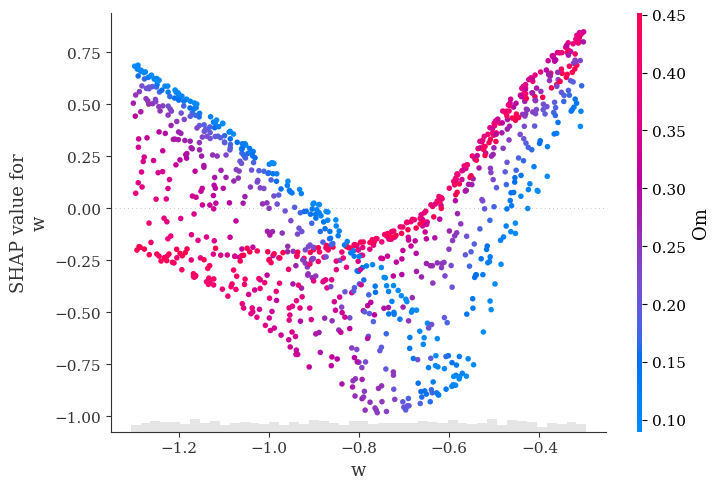

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_w.png')]

In [59]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2024 · wCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2024 · wCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="2-2"></a>2.2 wCDM with DES2025 — 2D (Om, w)

**Data:** DES SN5YR release 2025 (1820 SNe, SNANA format).
**Model:** `FlatwCDM` with H0 = 70 fixed.
**Cepheids:** **NO**.

The 2025 `STAT+SYS_2025.npz` matrix already provides the inverse of the full
STAT+SYS covariance as a packed upper triangle — the loader unpacks it and
uses it directly.


In [60]:
SECTION = "2_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]
H0_FIXED = 70.0

des = load_des_2025()
print(f"DES SN5YR 2025: {len(des)} SNe, z [{des.z.min():.3f}, {des.z.max():.3f}]")

def chi2_fn(Om, w):
    return chi2_sne_des(des, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3, -1.0])))
_m.limits = [(0.05, 0.55), (-1.6, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2025: 1820 SNe, z [0.025, 1.144]
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2611  w=-0.8327
chi2(best-fit) = 1639.03


In [61]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[dict(Om=(max(0.05, REF['Om']-0.20), REF['Om']+0.20),
                     w=(REF['w']-0.50, REF['w']+0.50), _n=8_000)],
        anchor=REF, n_anchor=2000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_2_dataset.csv)
Evaluating chi2 at 8000 points across 11 cores...


     2000/8000 ( 25.0%) | elapsed   94.1s | ETA  282.2s |     21 pts/s
     4000/8000 ( 50.0%) | elapsed  175.9s | ETA  175.9s |     23 pts/s
     6000/8000 ( 75.0%) | elapsed  251.2s | ETA   83.7s |     24 pts/s
     8000/8000 (100.0%) | elapsed  311.4s | ETA    0.0s |     26 pts/s
  done in 311.5s
  anchor {'Om': 0.2610591129421274, 'w': -0.8327127998802393} -> chi2=1639.030 repeated 2000x
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_2_dataset.csv (10000 rows)
min chi2 = 1639.030


In [62]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)

  target in shifted-log10: range [0.000, 3.182]
  training: 8.72s | R2=0.99885 | best_iter=548/3000  (early stop, ~82% saved)
  model cached: 2_2_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_learning_curve.png


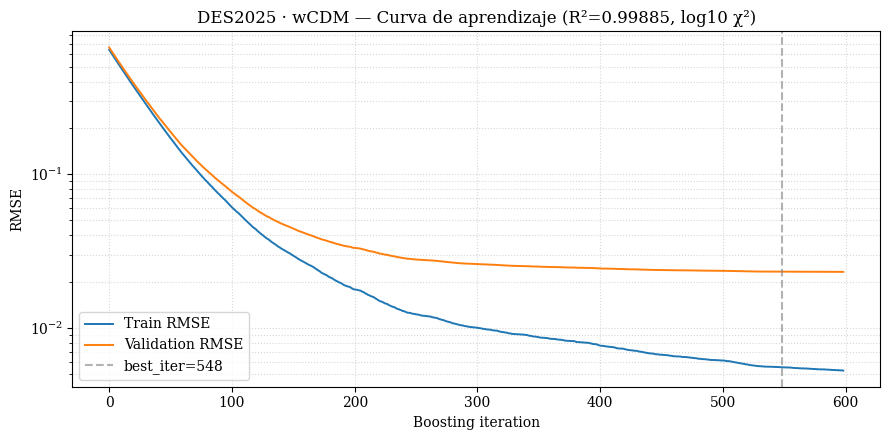

In [63]:
plot_learning_curve(
    info,
    title=f"DES2025 · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_Om_w.png


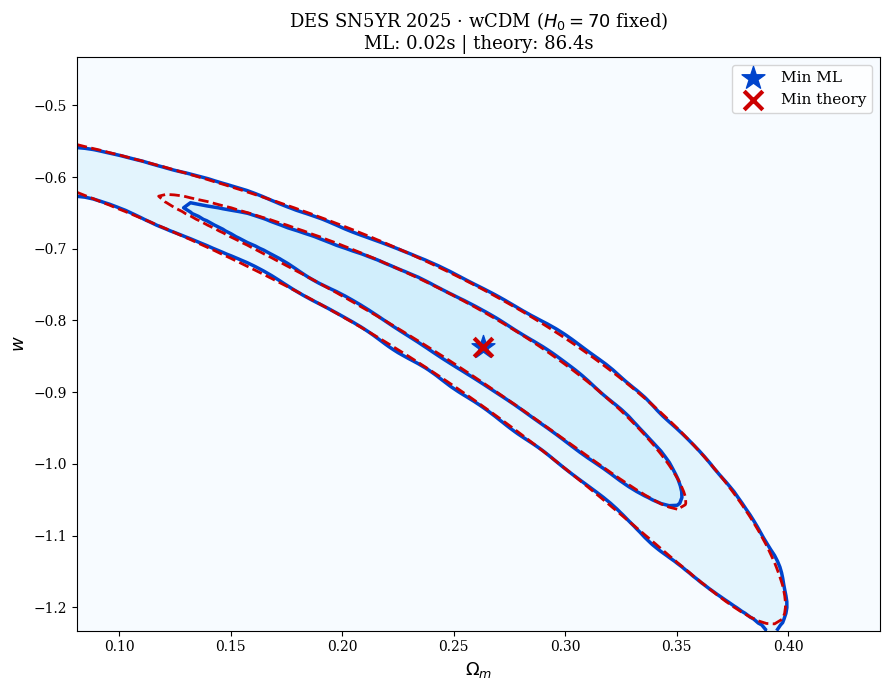

{'Z_ml': array([[2577.2625, 2564.6423, 2542.7097, ..., 1653.0618, 1653.8043,
         1654.2196],
        [2569.654 , 2557.0042, 2535.0454, ..., 1653.2487, 1654.0089,
         1654.434 ],
        [2555.4355, 2542.8013, 2520.9062, ..., 1653.592 , 1654.3857,
         1654.8296],
        ...,
        [1696.2461, 1696.8821, 1698.0127, ..., 1948.9152, 1950.7799,
         1951.8652],
        [1700.1012, 1700.7494, 1701.892 , ..., 1953.6912, 1955.5178,
         1956.58  ],
        [1702.2638, 1702.9137, 1704.0541, ..., 1956.395 , 1958.1996,
         1959.248 ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.017701387405395508,
 'time_th': 86.37097334861755}

In [64]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(REF['Om']-0.18, REF['Om']+0.18),
    y_range=(REF['w']-0.40, REF['w']+0.40),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DES SN5YR 2025 · wCDM ($H_0=70$ fixed)",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w.png",
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_beeswarm.png


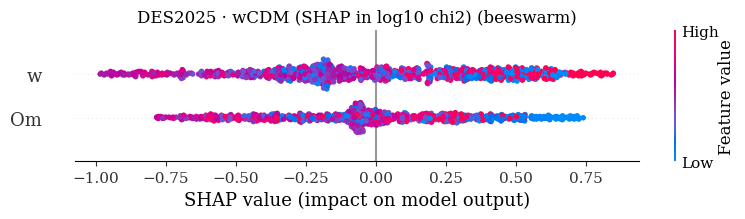

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_bar.png


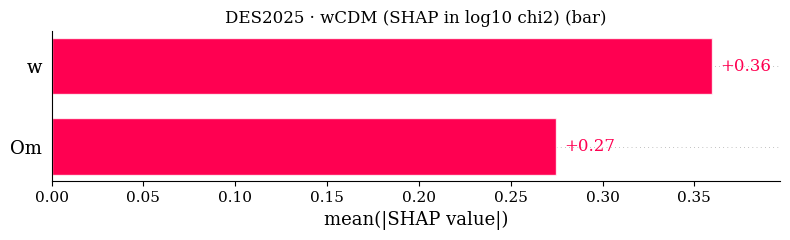

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_waterfall.png


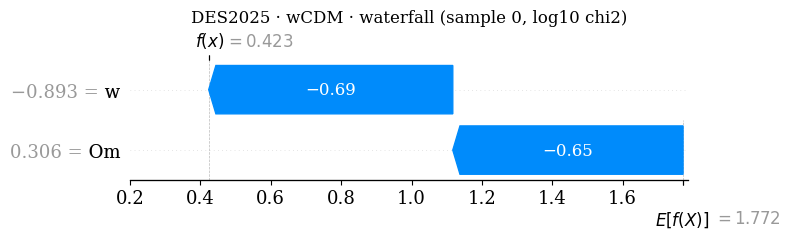

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

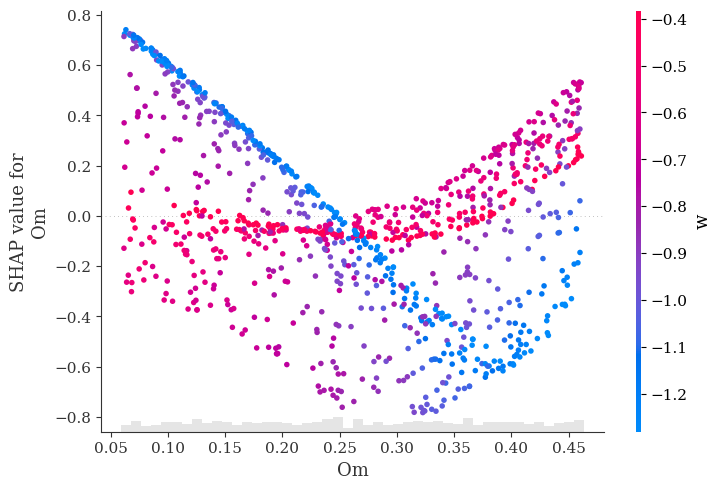

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_w.png


<Figure size 640x480 with 0 Axes>

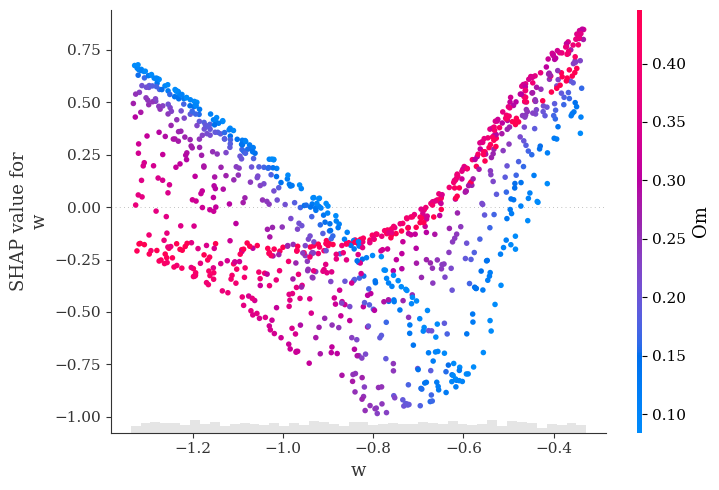

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_w.png')]

In [65]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2025 · wCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2025 · wCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="2-3"></a>2.3 w0waCDM with DES2024 — 3D (Om, w0, wa)

**Data:** DES-SN5YR 2024.
**Model:** `Flatw0waCDM` (CPL) with H0 = 70 fixed.
**Cepheids:** **NO**.


In [77]:
SECTION = "2_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
H0_FIXED = 70.0

des = load_des_2024()
print(f"DES SN5YR 2024: {len(des)} SNe")

def chi2_fn(Om, w0, wa):
    return chi2_sne_des(des, model="Flatw0waCDM", Om=Om, H0=H0_FIXED, w0=w0, wa=wa)

# SN-only w0waCDM: wa no está restringida por datos SN solos; se fija en 0 (referencia ΛCDM)
import types
from iminuit import Minuit
print("Locating best-fit (wa=0 fixed, SN-only)...")
_m = Minuit(lambda Om, w0: chi2_fn(Om=Om, w0=w0, wa=0.0), Om=0.3, w0=-1.0)
_m.limits = [(0.05, 0.6), (-2.5, 0.2)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), w0=float(_m.values['w0']), wa=0.0),
    x=[float(_m.values['Om']), float(_m.values['w0']), 0.0]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2024: 1829 SNe
Locating best-fit (wa=0 fixed, SN-only)...
Auto-detected best-fit:  Om=0.2670  w0=-0.8019  wa=0.0000
chi2(best-fit) = 1647.67


In [78]:
def builder():
    N = 5_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.0, 0.0), wa=(-4.0, 2.0), Om=REF['Om'], _n=N),
            dict(Om=(0.1, 0.5), w0=(-2.0, 0.0), wa=REF['wa'],  _n=N),
            dict(Om=(0.1, 0.5), wa=(-4.0, 2.0), w0=REF['w0'],  _n=N),
        ],
        random_box=dict(Om=(0.05, 0.65), w0=(-3.0, 0.5), wa=(-5.0, 4.0)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_3_dataset.csv)
Evaluating chi2 at 30000 points across 11 cores...
     2000/30000 (  6.7%) | elapsed   84.4s | ETA 1181.1s |     24 pts/s
     4000/30000 ( 13.3%) | elapsed  167.9s | ETA 1091.6s |     24 pts/s
     6000/30000 ( 20.0%) | elapsed  246.6s | ETA  986.3s |     24 pts/s
     8000/30000 ( 26.7%) | elapsed  331.7s | ETA  912.1s |     24 pts/s
    10000/30000 ( 33.3%) | elapsed  403.2s | ETA  806.4s |     25 pts/s
    12000/30000 ( 40.0%) | elapsed  474.1s | ETA  711.1s |     25 pts/s
    14000/30000 ( 46.7%) | elapsed  537.8s | ETA  614.6s |     26 pts/s
    16000/30000 ( 53.3%) | elapsed  614.3s | ETA  537.5s |     26 pts/s
    18000/30000 ( 60.0%) | elapsed  689.4s | ETA  459.6s |     26 pts/s
    20000/30000 ( 66.7%) | elapsed  766.0s | ETA  383.0s |     26 pts/s
    22000/30000 ( 73.3%) | elapsed  833.6s | ETA  303.1s |     26 pts/s
    24000/30000 ( 80.0%) | elapsed  903.7s | ETA  225.9s |  

  target in shifted-log10: range [0.000, 4.097]
  training: 22.15s | R2=0.99725 | best_iter=1012/3000  (early stop, ~66% saved)
  model cached: 2_3_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_learning_curve.png


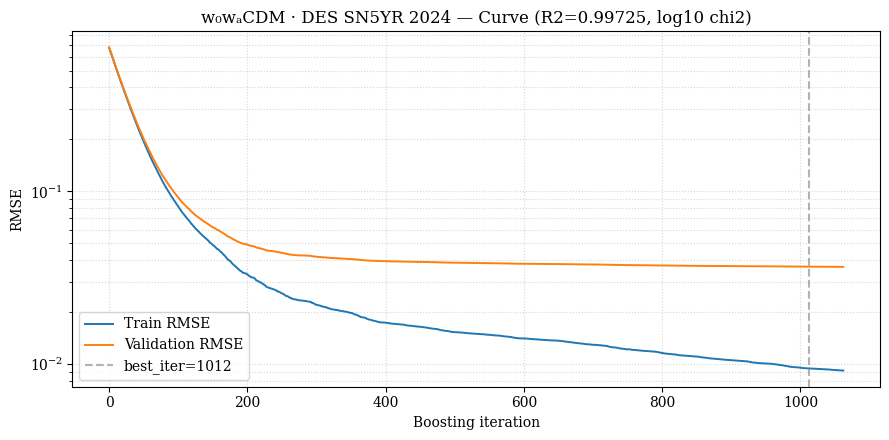

In [79]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM · DES SN5YR 2024 — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_Om_w0.png


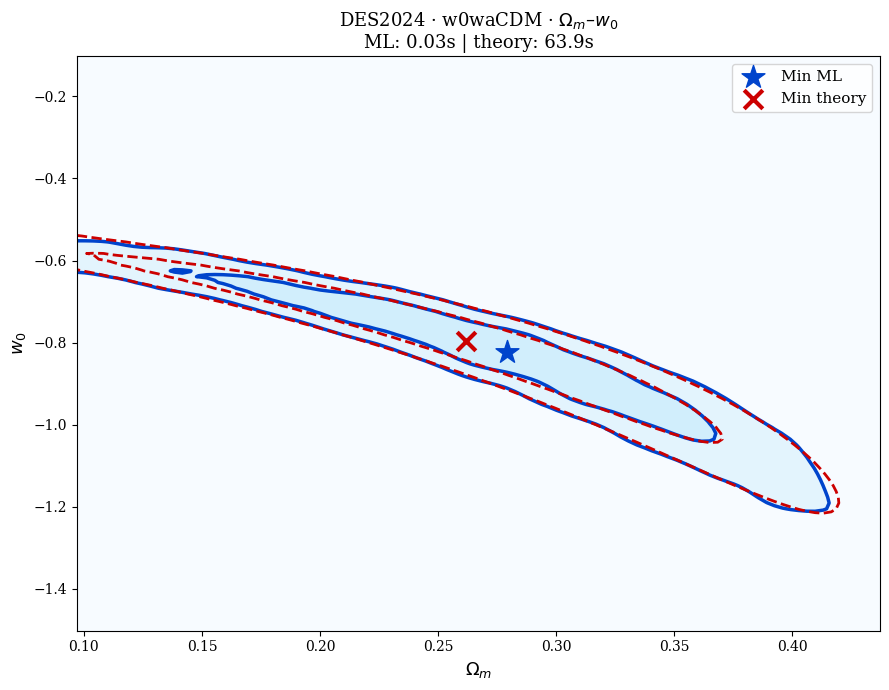

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8019061950675828}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_Om_wa.png


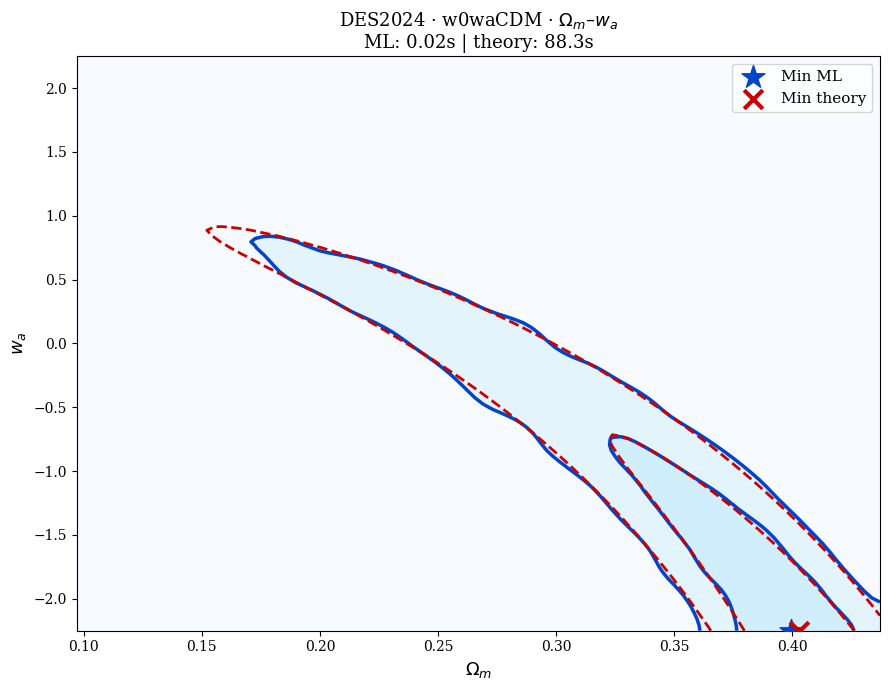

--- $w_a$ vs $w_0$  ({'Om': 0.26704995736857207}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_w0_wa.png


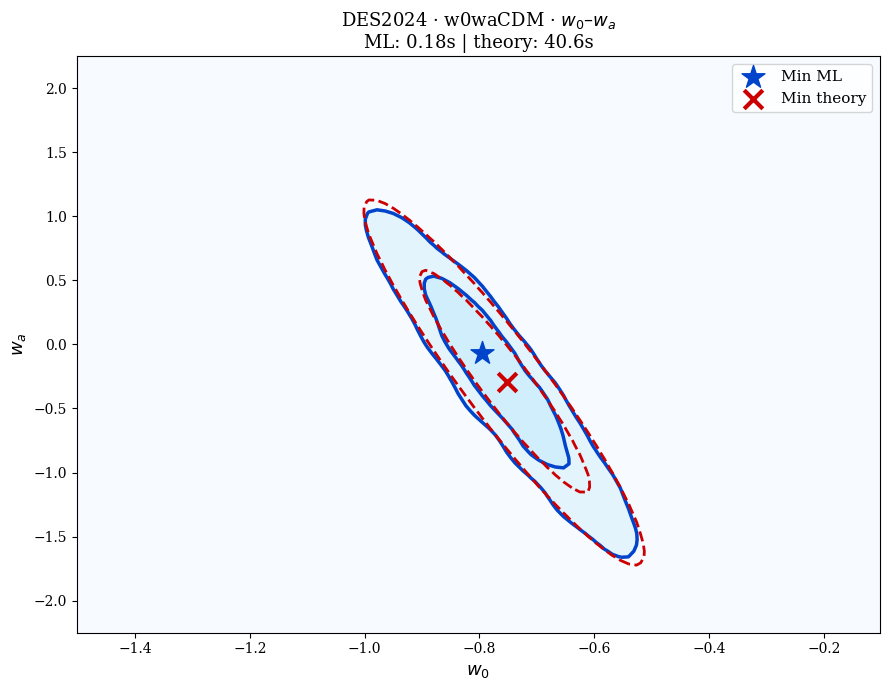

In [80]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.17, REF['Om']+0.17),
    w0=(REF['w0']-0.70, REF['w0']+0.70),
    wa=(REF['wa']-2.25, REF['wa']+2.25),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','w0'), ('Om','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DES2024 · w0waCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_beeswarm.png


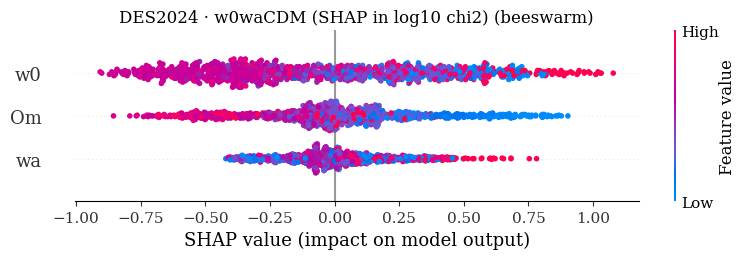

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_bar.png


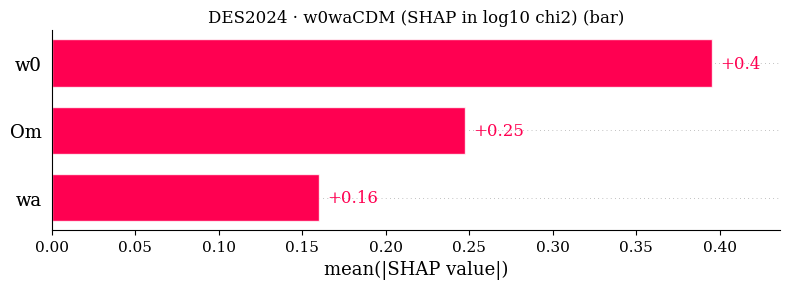

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_waterfall.png


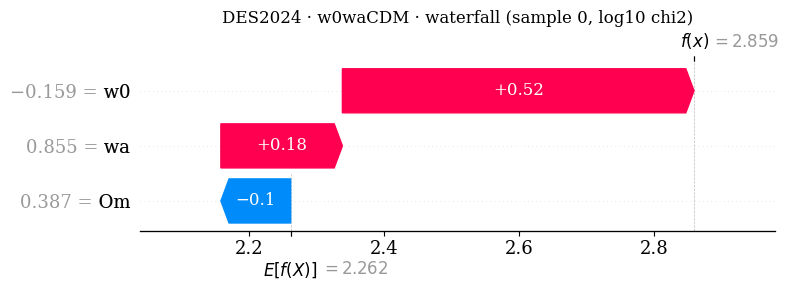

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

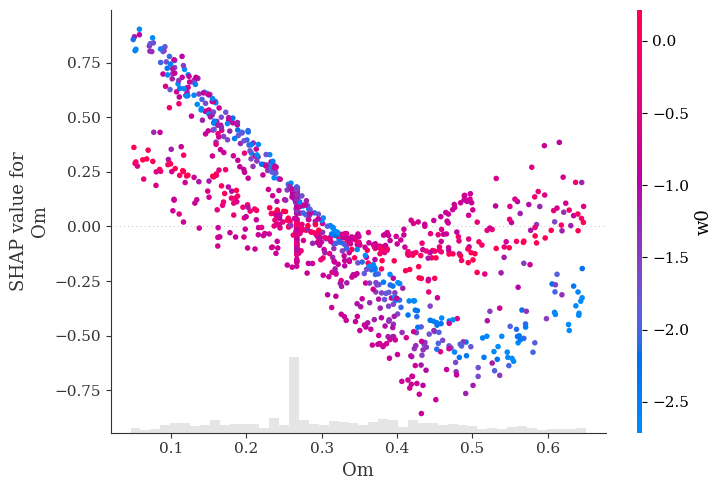

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_w0.png


<Figure size 640x480 with 0 Axes>

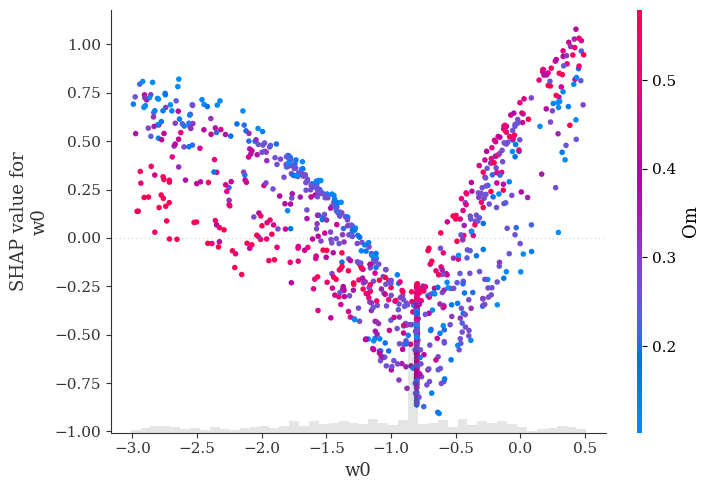

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_wa.png


<Figure size 640x480 with 0 Axes>

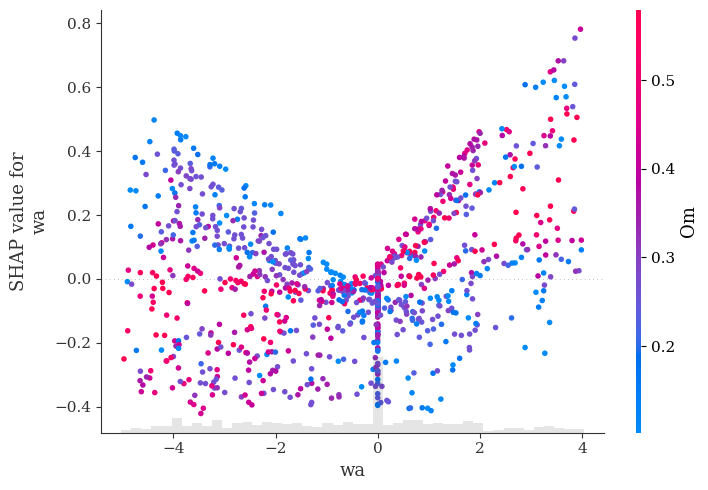

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_wa.png')]

In [81]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2024 · w0waCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2024 · w0waCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="2-4"></a>2.4 w0waCDM with DES2025 — 3D (Om, w0, wa)

**Data:** DES SN5YR 2025 (final release).
**Model:** `Flatw0waCDM` (CPL) with H0 = 70 fixed.
**Cepheids:** **NO**.


In [82]:
SECTION = "2_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
H0_FIXED = 70.0

des = load_des_2025()
print(f"DES SN5YR 2025: {len(des)} SNe")

def chi2_fn(Om, w0, wa):
    return chi2_sne_des(des, model="Flatw0waCDM", Om=Om, H0=H0_FIXED, w0=w0, wa=wa)

# SN-only w0waCDM: wa no está restringida por datos SN solos; se fija en 0 (referencia ΛCDM)
import types
from iminuit import Minuit
print("Locating best-fit (wa=0 fixed, SN-only)...")
_m = Minuit(lambda Om, w0: chi2_fn(Om=Om, w0=w0, wa=0.0), Om=0.3, w0=-1.0)
_m.limits = [(0.05, 0.6), (-2.5, 0.2)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), w0=float(_m.values['w0']), wa=0.0),
    x=[float(_m.values['Om']), float(_m.values['w0']), 0.0]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2025: 1820 SNe
Locating best-fit (wa=0 fixed, SN-only)...
Auto-detected best-fit:  Om=0.2611  w0=-0.8327  wa=0.0000
chi2(best-fit) = 1639.03


In [83]:
def builder():
    N = 5_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.5, 0.2), wa=(-3.5, 2.0), Om=REF['Om'], _n=N),
            dict(Om=(0.1, 0.6), w0=(-2.5, 0.2), wa=REF['wa'],  _n=N),
            dict(Om=(0.1, 0.6), wa=(-3.5, 2.0), w0=REF['w0'],  _n=N),
        ],
        random_box=dict(Om=(0.05, 0.65), w0=(-3.0, 0.5), wa=(-4.0, 3.0)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_4_dataset.csv)
Evaluating chi2 at 30000 points across 11 cores...
     2000/30000 (  6.7%) | elapsed   79.9s | ETA 1119.2s |     25 pts/s
     4000/30000 ( 13.3%) | elapsed  156.5s | ETA 1017.1s |     26 pts/s
     6000/30000 ( 20.0%) | elapsed  236.1s | ETA  944.4s |     25 pts/s
     8000/30000 ( 26.7%) | elapsed  308.0s | ETA  847.1s |     26 pts/s
    10000/30000 ( 33.3%) | elapsed  382.3s | ETA  764.5s |     26 pts/s
    12000/30000 ( 40.0%) | elapsed  450.7s | ETA  676.1s |     27 pts/s
    14000/30000 ( 46.7%) | elapsed  520.3s | ETA  594.7s |     27 pts/s
    16000/30000 ( 53.3%) | elapsed  596.8s | ETA  522.2s |     27 pts/s
    18000/30000 ( 60.0%) | elapsed  665.3s | ETA  443.5s |     27 pts/s
    20000/30000 ( 66.7%) | elapsed  746.2s | ETA  373.1s |     27 pts/s
    22000/30000 ( 73.3%) | elapsed  809.4s | ETA  294.3s |     27 pts/s
    24000/30000 ( 80.0%) | elapsed  881.2s | ETA  220.3s |  

  target in shifted-log10: range [0.000, 4.113]
  training: 18.88s | R2=0.99739 | best_iter=918/3000  (early stop, ~69% saved)
  model cached: 2_4_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_learning_curve.png


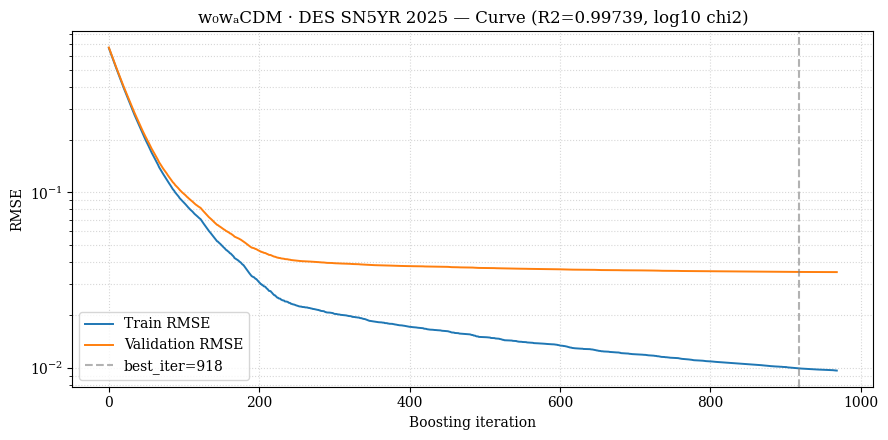

In [84]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM · DES SN5YR 2025 — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_Om_w0.png


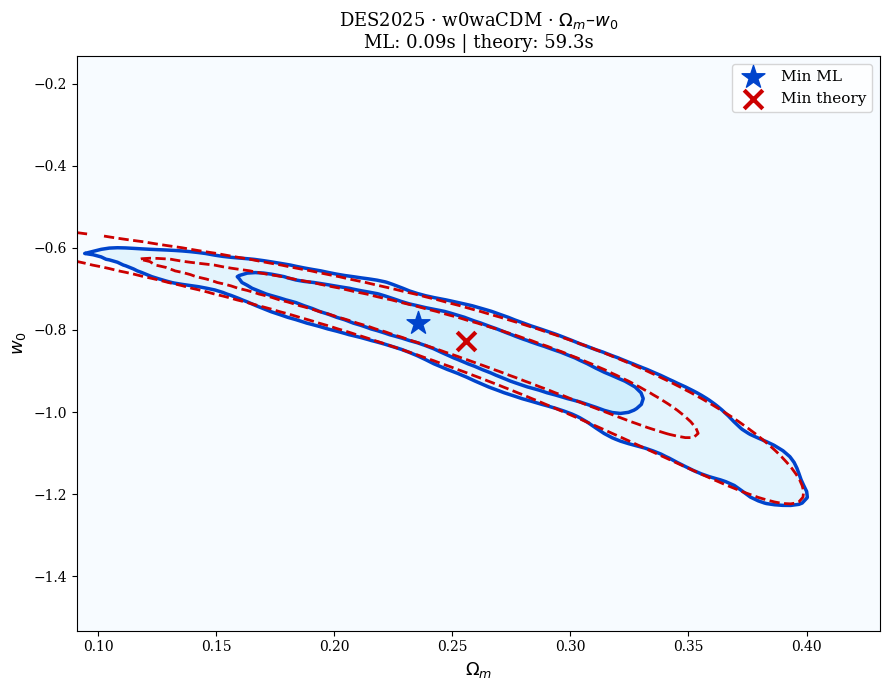

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8327492323119542}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_Om_wa.png


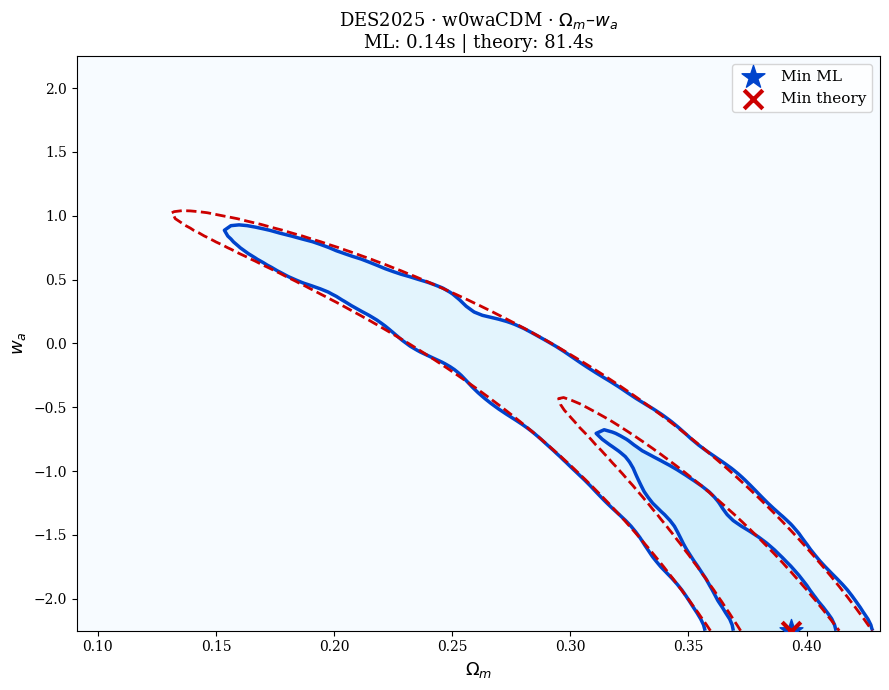

--- $w_a$ vs $w_0$  ({'Om': 0.26107362936495015}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_w0_wa.png


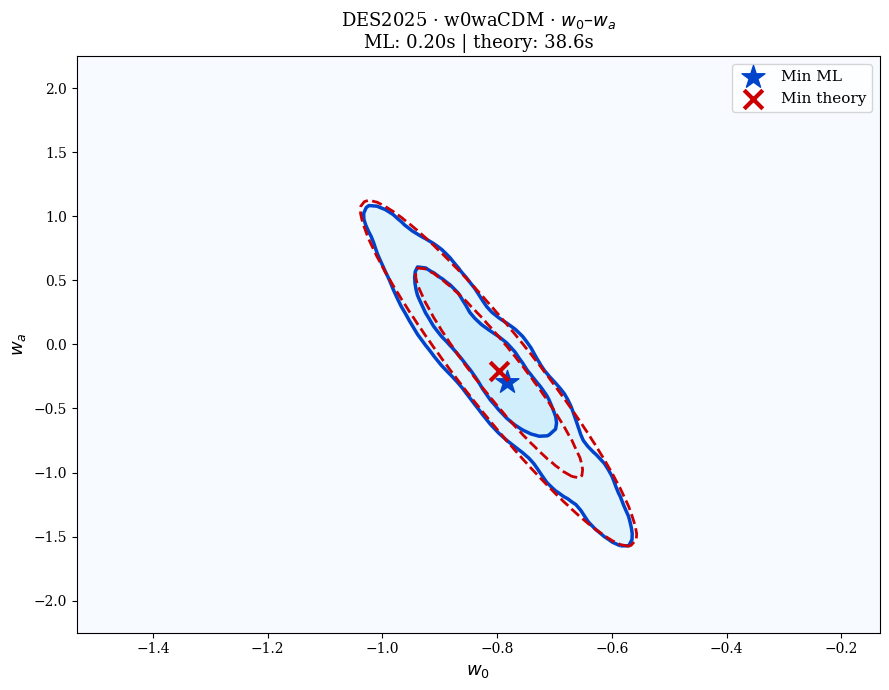

In [85]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.17, REF['Om']+0.17),
    w0=(REF['w0']-0.70, REF['w0']+0.70),
    wa=(REF['wa']-2.25, REF['wa']+2.25),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','w0'), ('Om','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DES2025 · w0waCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_beeswarm.png


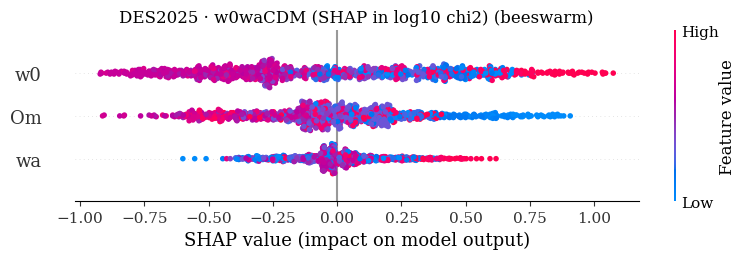

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_bar.png


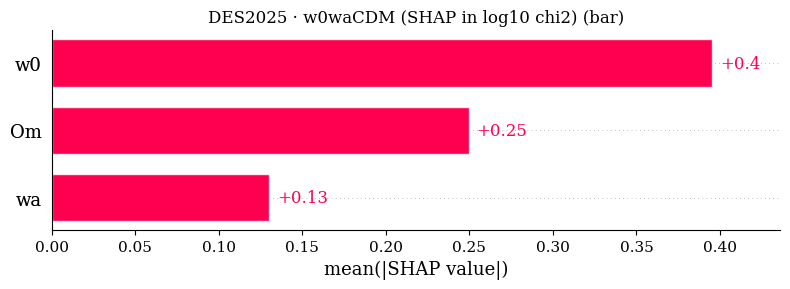

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_waterfall.png


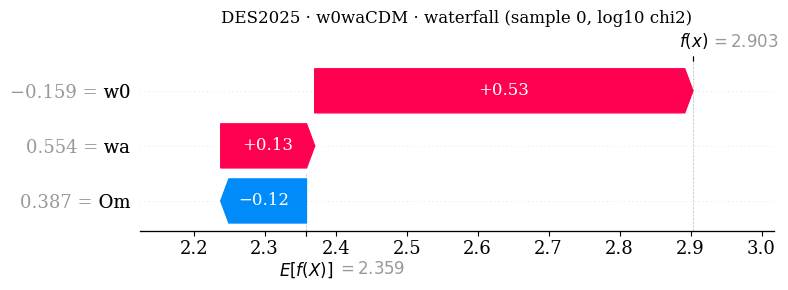

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

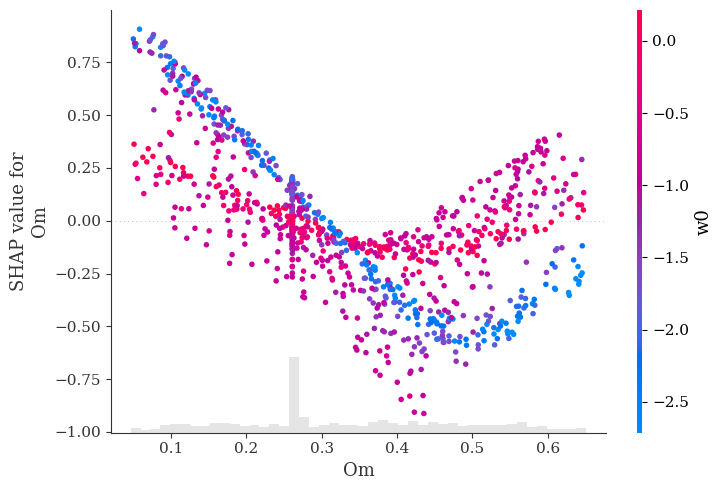

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_w0.png


<Figure size 640x480 with 0 Axes>

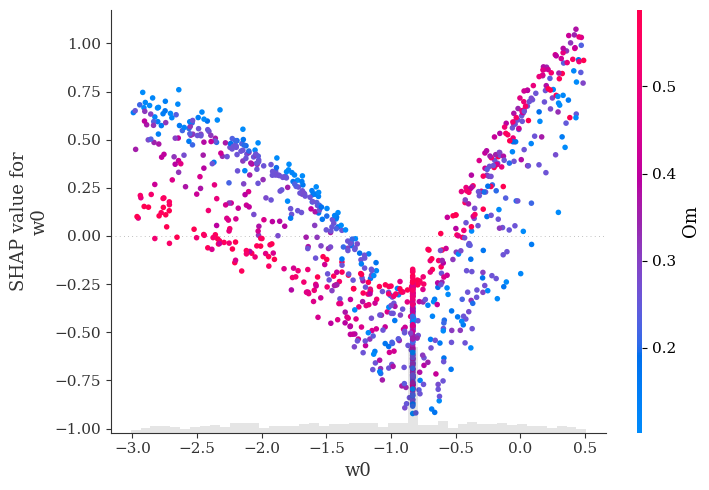

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_wa.png


<Figure size 640x480 with 0 Axes>

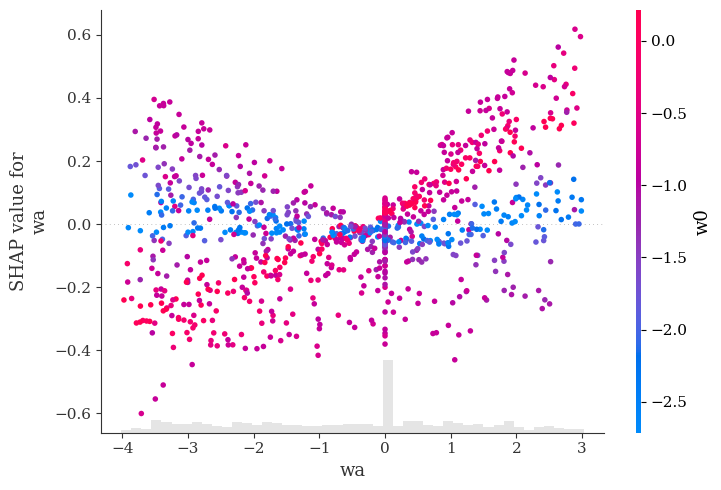

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_wa.png')]

In [86]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2025 · w0waCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2025 · w0waCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)